In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [14]:
df = pd.read_csv("battery_health_data.csv")

In [15]:
df.head(10)

,battery_id,cycle,avg_voltage_V,avg_current_A,temperature_C,charge_time_hr,discharge_time_hr,internal_resistance_ohm,capacity_Ah,soh_percent
0,1,1,4.2031,1.2660,22.689,2.0507,1.5094,0.04509,2.0882,100.29
1,1,2,4.2011,1.5936,24.189,2.1139,1.5429,0.04352,2.0732,99.57
2,1,3,4.1547,1.6059,24.123,2.0362,1.4866,0.04781,2.0808,99.93
3,1,4,4.1675,1.4583,24.424,2.0717,1.5382,0.04634,2.0744,99.63
4,1,5,4.1676,1.4393,23.336,2.0869,1.5776,0.04537,2.0906,100.40
5,1,6,4.1567,1.5790,24.761,2.0869,1.4789,0.04618,2.0645,99.15
6,1,7,4.1823,1.6056,24.390,2.0963,1.5160,0.04642,2.0700,99.41
7,1,8,4.1400,1.4628,23.675,2.0189,1.4982,0.04895,2.0719,99.51
8,1,9,4.2002,1.2994,23.599,2.0702,1.5358,0.04750,2.0578,98.83
9,1,10,4.1668,1.4460,24.742,2.0496,1.4449,0.04393,2.0689,99.36


In [16]:
df.tail(10)


,battery_id,cycle,avg_voltage_V,avg_current_A,temperature_C,charge_time_hr,discharge_time_hr,internal_resistance_ohm,capacity_Ah,soh_percent
9990,40,241,NaN,1.4128,25.623,2.4616,1.1213,0.07774,1.6613,79.60
9991,40,242,4.0493,1.4368,27.157,2.4152,1.0147,0.07443,1.6641,79.74
9992,40,243,4.0934,1.5780,27.967,2.5093,1.0899,0.07406,1.6681,79.93
9993,40,244,4.1675,1.5130,27.087,2.6273,1.1334,0.07092,1.6616,79.62
9994,40,245,4.0779,1.1962,26.250,2.4807,1.0836,0.07433,1.6712,80.08
9995,40,246,4.1010,1.6933,28.466,2.5147,0.9988,0.06951,1.6614,79.61
9996,40,247,4.0673,1.7167,27.595,2.4233,1.0714,0.07550,1.6600,79.54
9997,40,248,4.1060,1.4843,26.700,2.4358,1.1972,0.07437,1.6431,78.73
9998,40,249,4.0486,1.4900,27.222,NaN,1.1258,0.07690,1.6526,79.18
9999,40,250,4.0811,1.4586,26.770,2.4610,1.0712,0.07585,1.6540,79.25


In [17]:
df.describe()

,battery_id,cycle,avg_voltage_V,avg_current_A,temperature_C,charge_time_hr,discharge_time_hr,internal_resistance_ohm,capacity_Ah,soh_percent
count,10000.000000,10000.000000,9800.000000,9750.000000,9700.000000,9800.000000,9750.000000,9700.000000,10000.000000,10000.000000
mean,20.500000,125.500000,4.123755,1.518331,25.529225,2.301805,1.271680,0.060035,1.739780,86.986709
std,11.543974,72.171815,0.040961,0.120924,1.208222,0.157974,0.143890,0.008907,0.171312,7.892872
min,1.000000,1.000000,3.988100,1.052000,20.706000,1.894800,0.883100,0.041010,1.328700,66.660000
25%,10.750000,63.000000,4.093700,1.438300,24.677000,2.173975,1.156425,0.052550,1.614000,80.950000
50%,20.500000,125.500000,4.123800,1.517750,25.511500,2.304150,1.272600,0.060100,1.743700,87.330000
75%,30.250000,188.000000,4.153800,1.599000,26.394000,2.427200,1.386400,0.067520,1.871925,93.690000
max,40.000000,250.000000,4.250000,1.920300,29.429000,2.746700,1.659900,0.081090,2.141900,100.700000


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   battery_id               10000 non-null  int64  
 1   cycle                    10000 non-null  int64  
 2   avg_voltage_V            9800 non-null   float64
 3   avg_current_A            9750 non-null   float64
 4   temperature_C            9700 non-null   float64
 5   charge_time_hr           9800 non-null   float64
 6   discharge_time_hr        9750 non-null   float64
 7   internal_resistance_ohm  9700 non-null   float64
 8   capacity_Ah              10000 non-null  float64
 9   soh_percent              10000 non-null  float64
dtypes: float64(8), int64(2)
memory usage: 781.4 KB


In [19]:
df.shape

(10000, 10)

In [20]:
df.isnull().sum()

battery_id                   0
cycle                        0
avg_voltage_V              200
avg_current_A              250
temperature_C              300
charge_time_hr             200
discharge_time_hr          250
internal_resistance_ohm    300
capacity_Ah                  0
soh_percent                  0
dtype: int64

In [23]:
df["avg_voltage_V"].head()

0    4.2031
1    4.2011
2    4.1547
3    4.1675
4    4.1676
Name: avg_voltage_V, dtype: float64

In [24]:
df["avg_voltage_V"] = df["avg_voltage_V"].fillna(df["avg_voltage_V"].mean())

In [33]:
df["avg_voltage_V"].value_counts()

avg_voltage_V
4.123755    200
4.134600     18
4.147400     17
4.094900     16
4.142700     16
           ... 
4.226300      1
4.236600      1
4.207200      1
4.220300      1
4.228000      1
Name: count, Length: 1846, dtype: int64

In [35]:
df["avg_current_A"] = df["avg_current_A"].fillna(df["avg_current_A"].mean())

In [36]:
df["temperature_C"] = df["temperature_C"].fillna(df["temperature_C"].mean())

In [37]:
df["charge_time_hr"] = df["charge_time_hr"].fillna(df["charge_time_hr"].mean())

In [38]:
df["discharge_time_hr"] = df["discharge_time_hr"].fillna(df["discharge_time_hr"].mean())

In [39]:
df["internal_resistance_ohm"] = df["internal_resistance_ohm"].fillna(df["internal_resistance_ohm"].mean())

In [40]:
df.isnull().sum()

battery_id                 0
cycle                      0
avg_voltage_V              0
avg_current_A              0
temperature_C              0
charge_time_hr             0
discharge_time_hr          0
internal_resistance_ohm    0
capacity_Ah                0
soh_percent                0
dtype: int64

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   battery_id               10000 non-null  int64  
 1   cycle                    10000 non-null  int64  
 2   avg_voltage_V            10000 non-null  float64
 3   avg_current_A            10000 non-null  float64
 4   temperature_C            10000 non-null  float64
 5   charge_time_hr           10000 non-null  float64
 6   discharge_time_hr        10000 non-null  float64
 7   internal_resistance_ohm  10000 non-null  float64
 8   capacity_Ah              10000 non-null  float64
 9   soh_percent              10000 non-null  float64
dtypes: float64(8), int64(2)
memory usage: 781.4 KB


In [42]:
df.head()

,battery_id,cycle,avg_voltage_V,avg_current_A,temperature_C,charge_time_hr,discharge_time_hr,internal_resistance_ohm,capacity_Ah,soh_percent
0,1,1,4.2031,1.2660,22.689,2.0507,1.5094,0.04509,2.0882,100.29
1,1,2,4.2011,1.5936,24.189,2.1139,1.5429,0.04352,2.0732,99.57
2,1,3,4.1547,1.6059,24.123,2.0362,1.4866,0.04781,2.0808,99.93
3,1,4,4.1675,1.4583,24.424,2.0717,1.5382,0.04634,2.0744,99.63
4,1,5,4.1676,1.4393,23.336,2.0869,1.5776,0.04537,2.0906,100.40


In [46]:
df1 = df.drop(columns=["battery_id"],axis = 1)

In [48]:
df1.shape

(10000, 9)

In [50]:
df1.describe()

,cycle,avg_voltage_V,avg_current_A,temperature_C,charge_time_hr,discharge_time_hr,internal_resistance_ohm,capacity_Ah,soh_percent
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,125.500000,4.123755,1.518331,25.529225,2.301805,1.27168,0.060035,1.739780,86.986709
std,72.171815,0.040549,0.119402,1.189959,0.156386,0.14208,0.008772,0.171312,7.892872
min,1.000000,3.988100,1.052000,20.706000,1.894800,0.88310,0.041010,1.328700,66.660000
25%,63.000000,4.094400,1.440475,24.706750,2.177100,1.15950,0.052788,1.614000,80.950000
50%,125.500000,4.123755,1.518331,25.529225,2.301805,1.27168,0.060035,1.743700,87.330000
75%,188.000000,4.153225,1.596150,26.366250,2.424725,1.38400,0.067330,1.871925,93.690000
max,250.000000,4.250000,1.920300,29.429000,2.746700,1.65990,0.081090,2.141900,100.700000


In [63]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   cycle                    10000 non-null  int64  
 1   avg_voltage_V            10000 non-null  float64
 2   avg_current_A            10000 non-null  float64
 3   temperature_C            10000 non-null  float64
 4   charge_time_hr           10000 non-null  float64
 5   discharge_time_hr        10000 non-null  float64
 6   internal_resistance_ohm  10000 non-null  float64
 7   capacity_Ah              10000 non-null  float64
 8   soh_percent              10000 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 703.3 KB


Text(0.5, 1.0, 'Battery capacity vs Battery cycle')

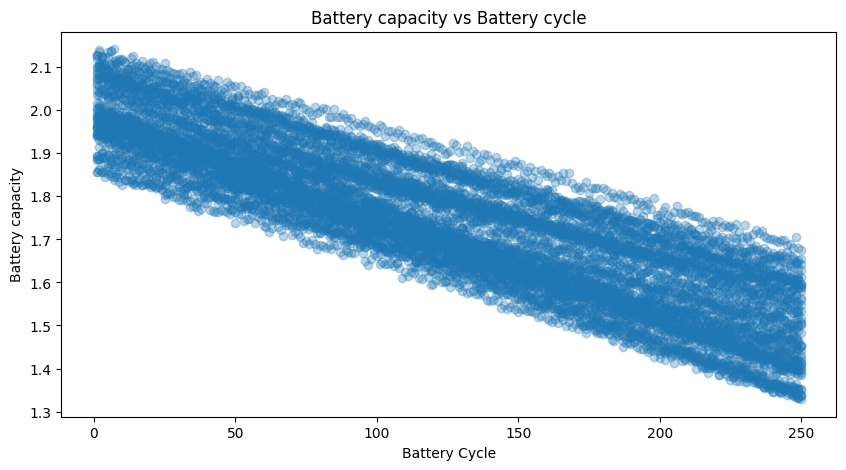

In [64]:
plt.figure(figsize=(10,5))
plt.scatter(df1["cycle"],df1["capacity_Ah"],alpha=0.3)

plt.xlabel("Battery Cycle")
plt.ylabel("Battery capacity")
plt.title("Battery capacity vs Battery cycle")

Text(0.5, 1.0, 'Battery cycle vs SOH_percent')

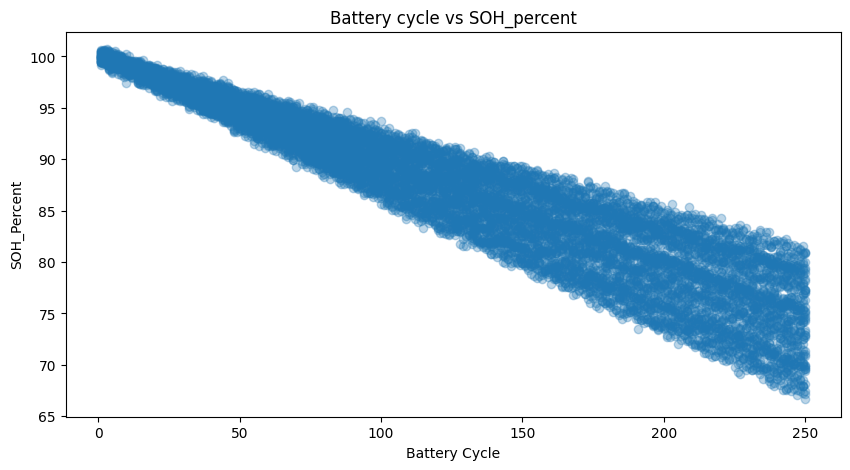

In [65]:
plt.figure(figsize=(10,5))
plt.scatter(df1["cycle"],df1["soh_percent"],alpha=0.3)

plt.xlabel("Battery Cycle")
plt.ylabel("SOH_Percent")
plt.title("Battery cycle vs SOH_percent")

In [66]:
correlation = df1.corr(numeric_only=True)
correlation["capacity_Ah"].sort_values(ascending=False)

capacity_Ah                1.000000
soh_percent                0.923125
discharge_time_hr          0.877125
avg_voltage_V              0.684525
avg_current_A             -0.073433
temperature_C             -0.635983
charge_time_hr            -0.818984
internal_resistance_ohm   -0.835017
cycle                     -0.871348
Name: capacity_Ah, dtype: float64

In [67]:
features = ["cycle","avg_voltage_V","avg_current_A","temperature_C","charge_time_hr","discharge_time_hr","internal_resistance_ohm"]

target = "capacity_Ah"

X = df[features]
y = df[target]

In [68]:
X.head()

,cycle,avg_voltage_V,avg_current_A,temperature_C,charge_time_hr,discharge_time_hr,internal_resistance_ohm
0,1,4.2031,1.2660,22.689,2.0507,1.5094,0.04509
1,2,4.2011,1.5936,24.189,2.1139,1.5429,0.04352
2,3,4.1547,1.6059,24.123,2.0362,1.4866,0.04781
3,4,4.1675,1.4583,24.424,2.0717,1.5382,0.04634
4,5,4.1676,1.4393,23.336,2.0869,1.5776,0.04537


In [69]:
y.head()

0    2.0882
1    2.0732
2    2.0808
3    2.0744
4    2.0906
Name: capacity_Ah, dtype: float64

In [78]:
split_cycle = int(df1["cycle"].max() * 0.8)
train_df1 = df1[df1["cycle"] <= split_cycle]
test_df1 = df1[df1["cycle"] > split_cycle]

print(train_df1.shape)
print(test_df1.shape)

(8000, 9)
(2000, 9)


In [75]:
X_train = train_df1[features]
y_train = train_df1[target]

In [76]:
X_test = test_df1[features]
y_test = test_df1[target]

In [77]:
print("X_train shape",X_train.shape)
print("y_train shape",y_train.shape)
print("X_test shape",X_test.shape)
print("y_test shape",y_test.shape)

X_train shape (8000, 7)
y_train shape (8000,)
X_test shape (2000, 7)
y_test shape (2000,)


In [82]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [83]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [84]:
y_pred = model.predict(X_test_scaled)

In [86]:
comparison = pd.DataFrame({"Actual": y_test.values,"Predicted": y_pred})

comparison.head(10)

,Actual,Predicted
0,1.6538,1.609151
1,1.6574,1.624407
2,1.6691,1.589369
3,1.6603,1.600266
4,1.6449,1.581653
5,1.6213,1.539139
6,1.6417,1.568266
7,1.6448,1.643783
8,1.6530,1.599436
9,1.6369,1.596020


In [87]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test,y_pred)

mae


0.07335655369430233

In [88]:
from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(y_test,y_pred)
rmse

0.0864889137617376

In [89]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test,y_pred)
r2

0.2730542850093096

Text(0.5, 1.0, 'Comparison between Actual vs Predicted Values')

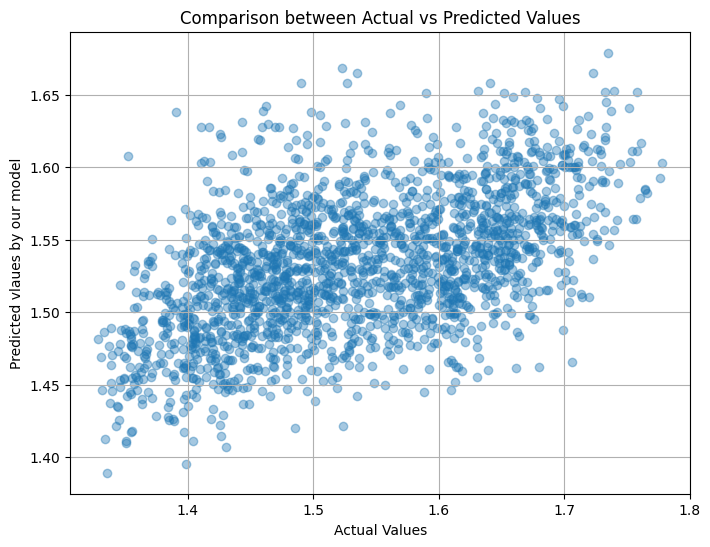

In [91]:
plt.figure(figsize = (8,6))
plt.scatter(y_test,y_pred,alpha=0.4)
plt.grid(True)
plt.xlabel("Actual Values")
plt.ylabel("Predicted vlaues by our model")
plt.title("Comparison between Actual vs Predicted Values")

In [93]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100,random_state=42)

rf.fit(X_train,y_train)
rf_pred = rf.predict(X_test)

In [94]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = root_mean_squared_error(y_test,y_pred)

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("mae :", rf_mae)
print("rmse:", rf_rmse)
print("r2  :", rf_r2)

Random Forest
mae : 0.08484114750000006
rmse: 0.0864889137617376
r2  : 0.008142566945009366


In [95]:
results = pd.DataFrame({"Model": ["Linear Regression","Random Forest"],"MAE": [mae,rf_mae],"RMSE": [rmse,rf_rmse],"R2": [r2,rf_r2]})

results

,Model,MAE,RMSE,R2
0,Linear Regression,0.073357,0.086489,0.273054
1,Random Forest,0.084841,0.086489,0.008143


In [100]:
initial_capacity = df["capacity_Ah"].iloc[0]

predicted_soh = (rf_pred / initial_capacity) * 100

In [110]:
prediction_result = pd.DataFrame({"Actual_Capacity": y_test.values,"Predicted_Capacity": rf_pred,"Predicted_SOH": predicted_soh})

prediction_result.head()

,Actual_Capacity,Predicted_Capacity,Predicted_SOH
0,1.6538,1.618737,77.518293
1,1.6574,1.635147,78.304138
2,1.6691,1.562769,74.838090
3,1.6603,1.589108,76.099416
4,1.6449,1.611890,77.190403


In [113]:
def classify_battery(soh):
    if soh > 80:
        return "Healthy"
    elif soh > 60:
        return "Aging"
    else:
        return "Needs Inspection"

prediction_result["Health_Status"] = (prediction_result["Predicted_SOH"].apply(classify_battery))

In [114]:
prediction_result.head(10)

,Actual_Capacity,Predicted_Capacity,Predicted_SOH,Health_Status
0,1.6538,1.618737,77.518293,Aging
1,1.6574,1.635147,78.304138,Aging
2,1.6691,1.562769,74.838090,Aging
3,1.6603,1.589108,76.099416,Aging
4,1.6449,1.611890,77.190403,Aging
5,1.6213,1.538357,73.669045,Aging
6,1.6417,1.540380,73.765923,Aging
7,1.6448,1.713355,82.049373,Healthy
8,1.6530,1.594329,76.349440,Aging
9,1.6369,1.617100,77.439900,Aging


In [120]:
def some_recommendation(status):
    if status == "Healthy":
        return "Continue using the Battery"
    elif status == "Aging":
        return "Check Battery Performace and plan the maintainance"
    else:
        return "Inspect Battery And Replacement"

    

In [121]:
prediction_result["Recommendation"] = (prediction_result["Health_Status"].apply(some_recommendation))

In [124]:
some_recommendation("Aging")
# some_recommendation("Healthy")
# some_recommendation("Needs Inspection")

'Check Battery Performace and plan the maintainance'